In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
DATA_PATH = os.path.join('..', 'data', 'processed', 'ncr_properties_cleaned.parquet')

# Load the Parquet file
df = pd.read_parquet(DATA_PATH)

print(f"Loaded {len(df)} rows from Parquet.")
df.sample()

Loaded 12324 rows from Parquet.


,title,url,city,location,price,price_raw,area,area_raw,bedrooms,bathrooms,...,gym,lift,parking,vastu_compliant,property_hash,scraped_at,society_name,sector,locality,price_per_sqft
2301,"3 BHK Flat for Sale in Sector 134, Noida Exp...",https://www.magicbricks.com/propertyDetails/3-...,Noida,Unknown,15000000,₹1.50 Cr₹8982 per sqft,1670.0,,3,0,...,0,0,0,0,006481cee2c332931fda4651dc37e42b,2026-02-02 15:29:04.177256,Independent/Authority,Sector 134,Noida,8982.0


In [4]:
df.columns.unique()

Index(['title', 'url', 'city', 'location', 'price', 'price_raw', 'area',
       'area_raw', 'bedrooms', 'bathrooms', 'balcony', 'prop_type',
       'furnished', 'facing', 'floor', 'pooja_room', 'servant_room',
       'store_room', 'pool', 'gym', 'lift', 'parking', 'vastu_compliant',
       'property_hash', 'scraped_at', 'society_name', 'sector', 'locality',
       'price_per_sqft'],
      dtype='object')

In [5]:
col = "sector"

print("Missing %:", df[col].isna().mean())
print("Unique:", df[col].nunique())
print(df[col].value_counts().head(10))


Missing %: 0.07586822460240182
Unique: 1234
sector
Noida Extension        829
Indirapuram            285
Raj Nagar Extension    244
Sector 150             194
Yamuna Expressway      155
National Highway 24    151
Sector 79              137
Sector 49              126
Sector 107             124
Sector 43              117
Name: count, dtype: int64


<Axes: xlabel='sector', ylabel='Count'>

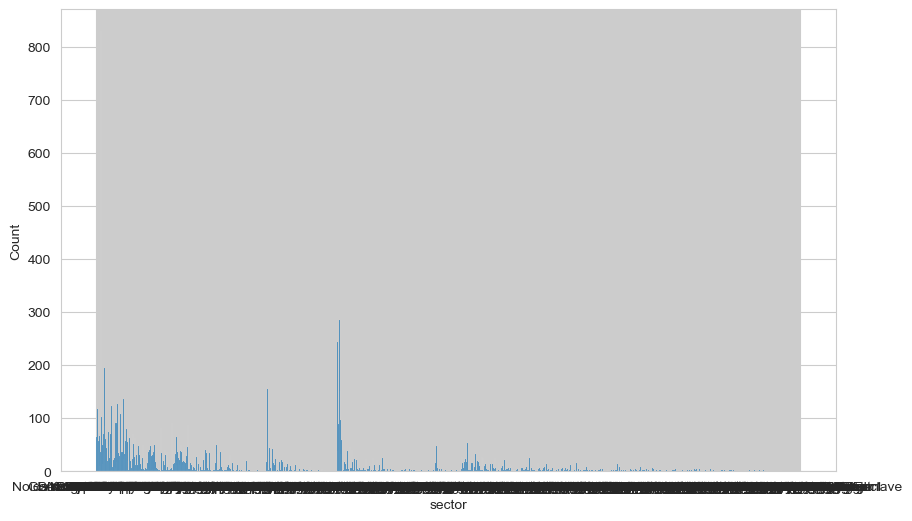

In [6]:
df[col].describe()
sns.histplot(df[col].dropna())


In [7]:
df["city"].isna().mean()
df["city"].nunique()
df["city"].value_counts()


city
Noida            3320
New Delhi        2506
Gurugram         2463
Ghaziabad        1926
Greater Noida    1559
Faridabad         550
Name: count, dtype: int64

In [8]:
df["city"] = df["city"].str.strip().str.title()


In [9]:
df["location"].isna().mean()
df["location"].nunique()
df["location"].value_counts().head(20)


location
Unknown    12324
Name: count, dtype: int64

In [10]:
df[["city","locality","sector"]].sample(5)


,city,locality,sector
1807,Noida,Noida,Noida Extension
4428,Gurugram,Gurgaon,Sohna
1001,Noida,Noida,None
2557,Noida,Noida,Sector 118
82,Noida,Noida,Sector 43


In [11]:
df["locality"] = df["locality"].replace({"Gurgaon": "Gurugram"})


In [12]:
(df["locality"] == df["city"]).mean()


0.9015741642323921

In [13]:
df.groupby(["city","locality"])["sector"].nunique().describe()


count    670.000000
mean       2.402985
std       25.401564
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max      579.000000
Name: sector, dtype: float64

In [14]:
df.groupby(["city","sector"])["locality"].nunique().describe()


count    1429.000000
mean        1.126662
std         0.413425
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
Name: locality, dtype: float64

In [15]:
df[df["locality"] != df["city"]]["locality"].value_counts().head(20)


locality
Noida Express Way Noida            29
Noida Extension Noida              29
Dadri Road Noida                   29
Mathura Road Faridabad             29
Noida Extension Greater Noida      21
Tilpata karanwas Greater Noida     12
Sangam Vihar New Delhi             11
Yamuna Expressway Greater Noida    11
Burari New Delhi                   10
Pusta Road Noida                    8
Govindpuram Ghaziabad               8
Sector 10 Greater Noida             8
Lal Kuan Ghaziabad                  8
Najafgarh New Delhi                 8
Indirapuram Ghaziabad               7
Golf course Metro Noida             7
Noida Noida                         7
Sector-Zeta Greater Noida           7
Uttam Nagar New Delhi               7
Sector 27 Greater Noida             7
Name: count, dtype: int64

In [16]:
df["city"].nunique()
df["city"].unique()
df["city"].value_counts()


city
Noida            3320
New Delhi        2506
Gurugram         2463
Ghaziabad        1926
Greater Noida    1559
Faridabad         550
Name: count, dtype: int64

In [17]:
delhi_df = df[df["city"] == "New Delhi"].copy()


In [18]:
delhi_df["sector"].value_counts().head(30)


sector
Dwarka               55
Uttam Nagar          54
Okhla                32
Kirti Nagar          27
Pitam Pura           27
Rohini               26
Vasant Kunj          26
Uttam Nagar West     25
Paschim Vihar        25
Sector 13            23
Chattarpur           23
Burari               21
Sector 9             20
Laxmi Nagar          20
Mehrauli             17
Vikaspuri            17
Kalkaji              17
Sector 6             17
Janakpuri            17
Narela               16
Saket                16
Nawada               16
Sector 23            15
Sector 22            15
Tilak Nagar          15
Mayur Vihar 1        15
Anand Vihar          15
Greater Kailash 1    15
Shahdara             15
Malviya Nagar        15
Name: count, dtype: int64

In [19]:
delhi_df = df[df["city"] == "New Delhi"].copy()



In [20]:
delhi_df.groupby("sector")["price_per_sqft"] \
    .median() \
    .sort_values(ascending=False) \
    .head(10)


sector
Sidora Kalan                        50000.0
New Rajdhani Enclave                46250.0
Ramprastha Greens                   44883.0
Vasant Vihar                        42000.0
Prashant Vihar                      41176.0
Nizamuddin                          40277.5
Defence Colony                      39322.0
Jamia Nagar                         38660.0
Geetanjali Enclave Malviya Nagar    38562.0
Okhla Industrial Area               38062.0
Name: price_per_sqft, dtype: float64

In [21]:
delhi_df.groupby("sector")["price_per_sqft"] \
    .median() \
    .sort_values() \
    .head(10)


sector
Mohammadpur                    2002.0
Tara Nagar                     2400.0
Raj Nagar 2 Extension          2500.0
Prahladpur Delhi Cantonment    2667.0
Khayala                        3000.0
Baprola                        3111.0
Sector 39                      3130.0
Pocket 7 Durga Park Colony     3184.0
Om Nagar Mithapur Extension    3200.0
Chander Vihar Nilothi          3273.0
Name: price_per_sqft, dtype: float64

In [22]:
sector_counts = delhi_df["sector"].value_counts()

valid_sectors = sector_counts[sector_counts >= 15].index

delhi_df[delhi_df["sector"].isin(valid_sectors)] \
    .groupby("sector")["price_per_sqft"] \
    .median() \
    .sort_values(ascending=False)


sector
Greater Kailash 1    32222.0
Vasant Kunj          20405.5
Kirti Nagar          19048.0
Okhla                17318.0
Kalkaji              17083.0
Sector 9             17054.0
Pitam Pura           16667.0
Anand Vihar          15294.0
Sector 22            15000.0
Mayur Vihar 1        14857.0
Sector 13            14286.0
Sector 6             14167.0
Janakpuri            14074.0
Paschim Vihar        14050.0
Vikaspuri            12400.0
Malviya Nagar        12296.0
Rohini               10915.5
Sector 23            10870.0
Tilak Nagar           8411.0
Saket                 7333.5
Laxmi Nagar           7137.5
Dwarka                7071.0
Chattarpur            6923.0
Narela                6137.5
Shahdara              6111.0
Mehrauli              5417.0
Uttam Nagar           5333.0
Nawada                5149.0
Uttam Nagar West      4839.0
Burari                4630.0
Name: price_per_sqft, dtype: float64

In [23]:
df["society_name"].isna().mean()
df["society_name"].nunique()
df["society_name"].value_counts().head(20)


society_name
Independent/Authority                6505
GODREJ ZENITH                          34
Block A                                33
Block B                                32
Greenfield Colony                      24
Sushant Lok-I                          22
Smart World Gems                       21
Amrapali Golf Homes                    21
Amrapali Dream Valley High Life 2      21
Block D                                19
Smartworld Sky ARC                     18
Sainik Colony                          18
Godrej Aristocrat                      18
Gaur Yamuna City                       18
Ajnara Le Garden                       17
Purvanchal Royal City                  16
DLF Ankur Vihar                        16
Godrej South Estate                    16
Prateek Grand City                     15
M3M Capital                            15
Name: count, dtype: int64

In [24]:
df.groupby(["city","sector"])["society_name"] \
  .nunique() \
  .describe()


count    1429.000000
mean        2.627012
std         5.519141
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       117.000000
Name: society_name, dtype: float64

In [25]:
soc_counts = df["society_name"].value_counts()
soc_counts.describe(percentiles=[0.25,0.5,0.75,0.9,0.95])


count    2214.000000
mean        5.566396
std       138.222751
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
90%         6.000000
95%         8.000000
max      6505.000000
Name: count, dtype: float64

In [26]:
delhi_df = df[df["city"]=="New Delhi"]

delhi_df.groupby(["sector","society_name"])["price_per_sqft"] \
    .median() \
    .reset_index() \
    .sort_values("price_per_sqft", ascending=False) \
    .head(20)


,sector,society_name,price_per_sqft
1000,Sidora Kalan,Independent/Authority,50000.0
206,Defence Colony,Defence colony Villas,49938.0
819,Sector 13,Aradhana Apartments,49708.0
1086,Vasant Vihar,Vasant Vihar Builder Floor,48280.0
299,Greater Kailash,Independent/Authority,46429.0
580,New Rajdhani Enclave,Independent/Authority,46250.0
736,Ramprastha Greens,Independent/Authority,44883.0
283,Geetanjali Enclave Malviya Nagar,DDA Geetanjali Enclave Project,44444.0
227,Dwarka,Adarsh Homes,43333.0
334,Hauz Khas,Safdarjung Development Area,43210.0


In [27]:
soc_counts = df["society_name"].value_counts()
(soc_counts >= 20).sum()


9

In [28]:
pd.crosstab(
    df["prop_type"],
    df["society_name"] == "Independent/Authority",
    normalize="index"
)


society_name,False,True
prop_type,,
Apartment,0.516428,0.483572
Builder Floor,0.361882,0.638118
Independent House,0.317708,0.682292
Plot,0.540000,0.460000


In [29]:
df.groupby("prop_type")["society_name"].nunique()


prop_type
Apartment            1945
Builder Floor         210
Independent House     450
Plot                   45
Name: society_name, dtype: int64

In [30]:
df[df["prop_type"]=="Apartment"]["society_name"].value_counts().head(20)


society_name
Independent/Authority                4489
GODREJ ZENITH                          28
Block B                                24
Amrapali Dream Valley High Life 2      20
Amrapali Golf Homes                    19
Smart World Gems                       18
Smartworld Sky ARC                     18
Block A                                17
Gaur Yamuna City                       17
Purvanchal Royal City                  15
Ajnara Le Garden                       15
Greenfield Colony                      15
M3M Capital                            15
M3M Golf Hills Phase 1                 14
Godrej South Estate                    14
Unitech Horizon                        14
DLF Ankur Vihar                        14
Godrej Aristocrat                      14
Prateek Grand City                     14
Eldeco La Vida Bella                   13
Name: count, dtype: int64

In [31]:
df.groupby("city")["price_per_sqft"].describe()


,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Faridabad,550.0,7409.339394,4306.619636,1543.0,4895.25,6509.5,8438.25,44000.0
Ghaziabad,1926.0,7473.035883,4296.512757,1571.0,4712.50,6667.0,9177.00,50000.0
Greater Noida,1559.0,8581.496187,4088.171857,2211.0,6032.00,8157.0,10366.50,45714.0
Gurugram,2463.0,14390.737718,6299.498963,2222.0,10485.50,13388.0,17222.50,50000.0
New Delhi,2506.0,12788.110535,8701.073702,1515.0,6111.00,10203.5,16924.75,50000.0
Noida,3320.0,11370.920582,6291.448233,1514.0,6916.50,10170.5,14300.00,49031.0


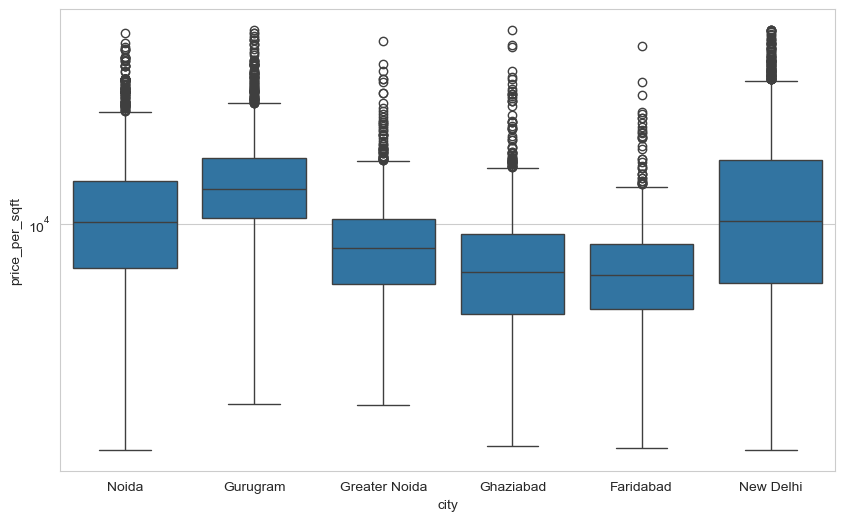

In [32]:
sns.boxplot(data=df, x="city", y="price_per_sqft")
plt.yscale("log")
plt.show()


### Observation
- Clear separation in median log price per sqft across cities.
- Gurugram has the highest central tendency.
- New Delhi and Noida follow as upper-tier markets.
- Greater Noida, Ghaziabad, and Faridabad form a lower-priced cluster.
- New Delhi exhibits the widest interquartile range, indicating strong intra-city heterogeneity.
- Outliers exist in all cities, particularly in premium segments.

### Insight
- NCR is composed of distinct city-level pricing regimes rather than a uniform market.
- Gurugram and New Delhi represent premium zones with high price concentration.
- Peripheral cities compete primarily on affordability.
- Within-city variation (especially in Delhi) suggests strong micro-market segmentation.

### Modeling Impact
- `city` should be treated as a core geographic feature.
- City-level baselines provide a strong starting point for pricing.
- Sector-level modeling must be conditioned within city boundaries.
- Geographic features will likely contribute more signal than many structural features alone.

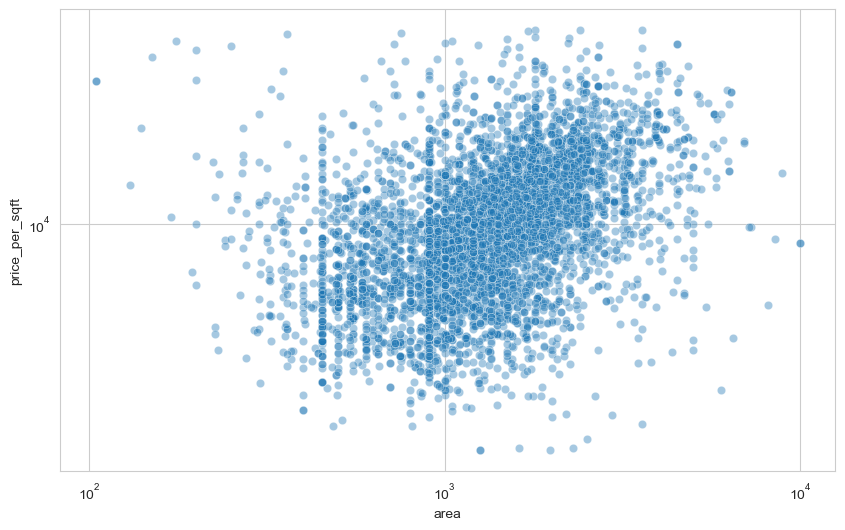

In [33]:
sns.scatterplot(
    data=df.sample(min(5000,len(df))),
    x="area",
    y="price_per_sqft",
    alpha=0.4
)
plt.xscale("log")
plt.yscale("log")
plt.show()


### Observation
- A clear positive relationship exists between area and log(price per sqft).
- The relationship appears approximately linear in log-log space.
- Most listings cluster around 800–2000 sqft.
- Variance is moderate across mid-sized properties and increases slightly at larger sizes.
- A sparse tail of very large properties contributes to upper-end dispersion.

### Insight
- Area is a strong structural driver of price efficiency.
- Log transformation effectively stabilizes the relationship and reduces heteroscedasticity.
- Larger properties tend to belong to premium market segments.
- No strong diminishing-return pattern is observed within this dataset.

### Modeling Impact
- Use `log(area)` as a primary continuous feature.
- Tree-based models can capture residual non-linearity naturally.
- Monitor extreme large-area listings during outlier handling.
- Consider potential interaction between area and geographic features for improved performance.


In [34]:
pd.crosstab(df["prop_type"], df["lift"], normalize="index")


lift,0,1
prop_type,,
Apartment,0.953571,0.046429
Builder Floor,0.885404,0.114596
Independent House,0.880208,0.119792
Plot,0.830000,0.170000


In [35]:
df.groupby(["prop_type","lift"])["price_per_sqft"].median()


prop_type          lift
Apartment          0        9486.0
                   1       10000.0
Builder Floor      0        8576.0
                   1       13542.0
Independent House  0       10091.0
                   1       11296.0
Plot               0       11503.0
                   1       13889.0
Name: price_per_sqft, dtype: float64

In [36]:
df.groupby(["city","sector"])["price_per_sqft"].median().describe()


count     1429.000000
mean     11324.398336
std       7308.359333
min       1852.000000
25%       6061.000000
50%       9242.000000
75%      14353.000000
max      50000.000000
Name: price_per_sqft, dtype: float64

In [37]:
df["property_hash"].nunique(), len(df)


(10638, 12324)

In [38]:
dup_groups = df.groupby("property_hash")

dup_groups[["price","area","bedrooms","bathrooms","sector"]].nunique().describe()


,price,area,bedrooms,bathrooms,sector
count,10638.0,10638.0,10638.0,10638.0,10638.000000
mean,1.0,1.0,1.0,1.0,0.918782
std,0.0,0.0,0.0,0.0,0.273183
min,1.0,1.0,1.0,1.0,0.000000
25%,1.0,1.0,1.0,1.0,1.000000
50%,1.0,1.0,1.0,1.0,1.000000
75%,1.0,1.0,1.0,1.0,1.000000
max,1.0,1.0,1.0,1.0,1.000000


In [39]:
df = df.drop_duplicates(subset=["property_hash"])


In [40]:
df[df["property_hash"].duplicated(keep=False)] \
    .sort_values("property_hash") \
    .head(5)


,title,url,city,location,price,price_raw,area,area_raw,bedrooms,bathrooms,...,gym,lift,parking,vastu_compliant,property_hash,scraped_at,society_name,sector,locality,price_per_sqft


In [41]:
conflict = dup_groups["price"].nunique() > 1
conflict.sum()


0

In [42]:
(dup_groups["area"].nunique() > 1).sum()


0